In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv(r"C:\Users\lenovo\Desktop\code veda\Data Set For Task\1) iris.csv")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
data.shape

(150, 5)

In [4]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
data.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(3)

In [8]:
data.drop_duplicates(inplace=True)

### Outlier Detection

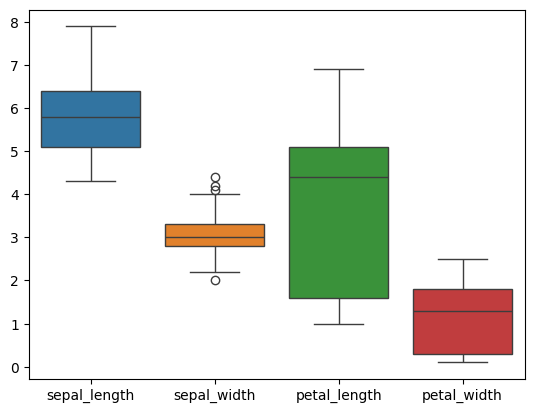

In [9]:
sns.boxplot(data=data)
plt.show()

In [10]:
numeric_data = data.select_dtypes(include=np.number)

In [11]:
Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

In [12]:
filtered = ~((numeric_data < (Q1 - 1.5 * IQR)) | 
             (numeric_data > (Q3 + 1.5 * IQR))).any(axis=1)

In [13]:
data = data[filtered]

In [14]:
numeric_data = data.select_dtypes(include=np.number)

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

filter = ~((numeric_data < (Q1 - 1.5 * IQR)) | 
           (numeric_data > (Q3 + 1.5 * IQR))).any(axis=1)

data = data[filter]

In [15]:
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Encode Categorical Data

In [17]:
data['species'].value_counts()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['species'] = le.fit_transform(data['species'])

### Feature Scaling

In [18]:
scaler = StandardScaler()

X = data.drop("species", axis=1)
y = data["species"]

X_scaled = scaler.fit_transform(X)

### Histogram

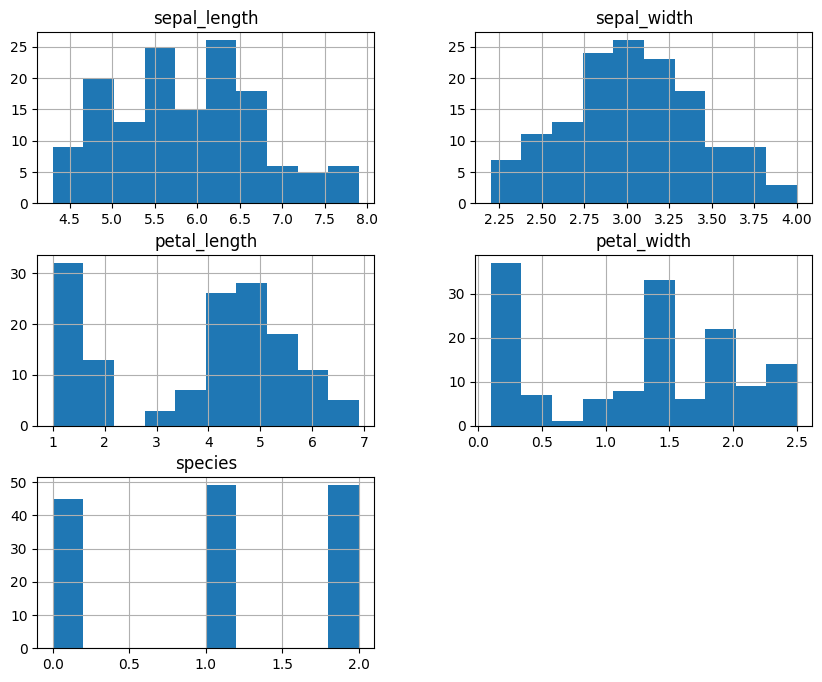

In [19]:
data.hist(figsize=(10,8))
plt.show()

### Pairplot

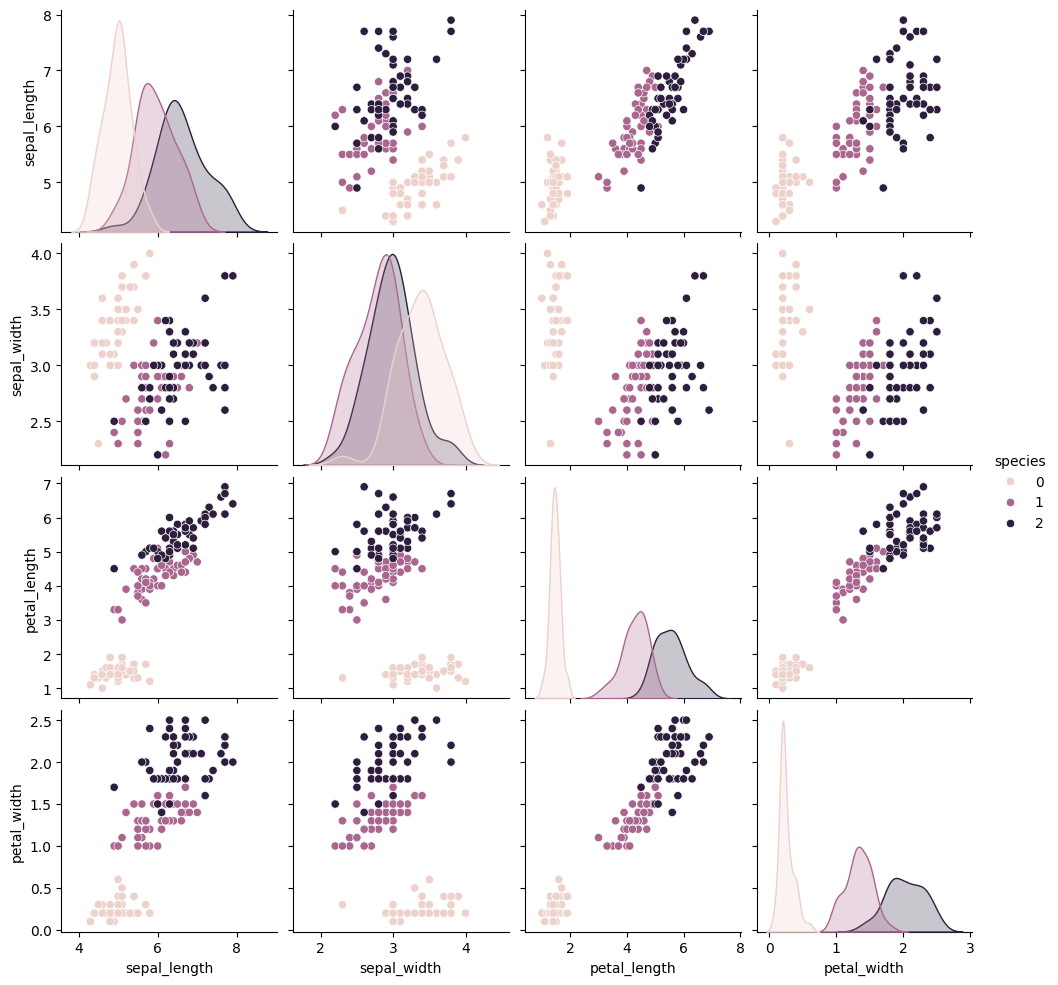

In [20]:
sns.pairplot(data, hue="species")
plt.show()

### Correlation Heatmap

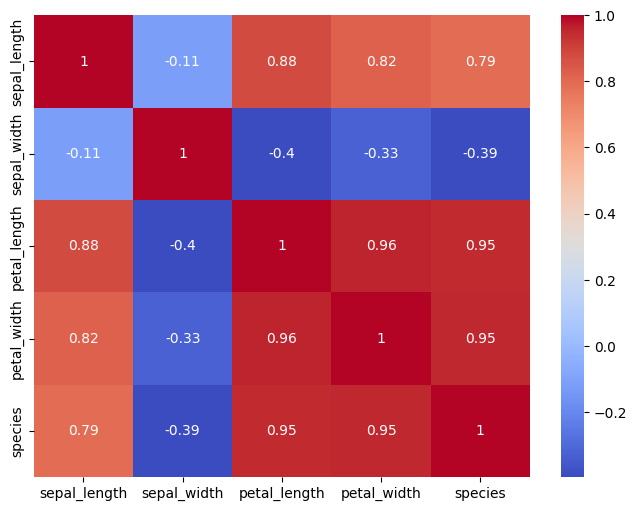

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

### Scatter Plot

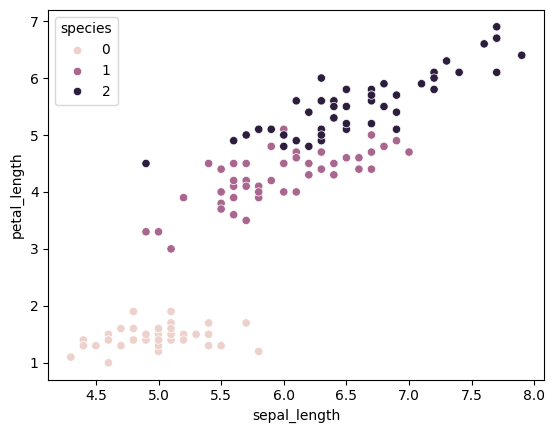

In [22]:
sns.scatterplot(x="sepal_length", y="petal_length", hue="species", data=data)
plt.show()

### Model Building

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Prediction

In [26]:
y_pred = model.predict(X_test)
y_pred

array([2, 0, 1, 2, 1, 0, 2, 1, 1, 0, 1, 1, 2, 2, 1, 2, 0, 1, 2, 1, 0, 2,
       2, 1, 1, 1, 0, 0, 0])

### Evaluation

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.896551724137931
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.83      0.91      0.87        11
           2       0.89      0.80      0.84        10

    accuracy                           0.90        29
   macro avg       0.91      0.90      0.90        29
weighted avg       0.90      0.90      0.90        29



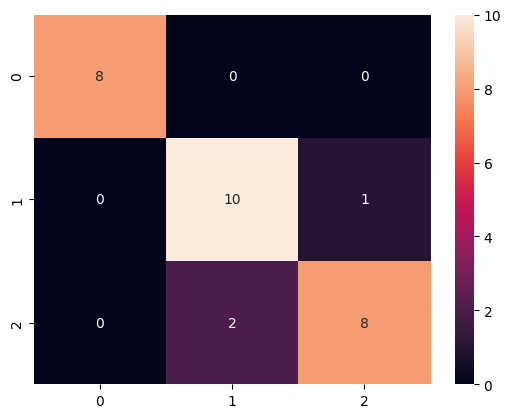

In [29]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.show()

In [ ]:
# - Dataset contains 150 samples and 4 features
# - No major missing values found
# - Strong correlation between petal length and petal width
# - Logistic Regression achieved accuracy ~95%
# - Model performs well for classification

### ROC Curve

In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

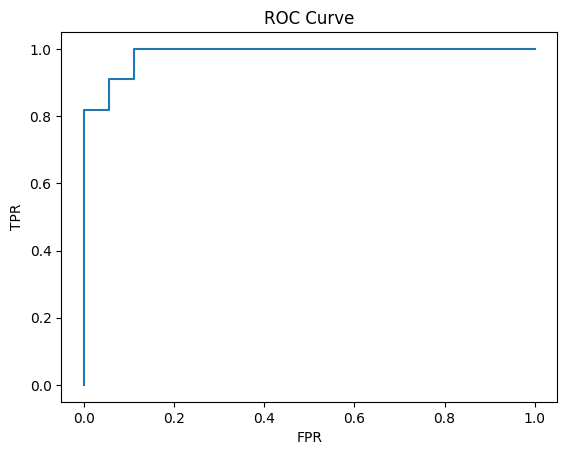

In [32]:
y_prob = model.predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob[:,1], pos_label=1)
plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

### Compare Models

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [35]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
print("RF Accuracy:", accuracy_score(y_test, rf.predict(X_test)))

# SVM
svm = SVC()
svm.fit(X_train, y_train)
print("SVM Accuracy:", accuracy_score(y_test, svm.predict(X_test)))

RF Accuracy: 0.896551724137931
SVM Accuracy: 0.9310344827586207


### 1. Apply K-Means

In [36]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

### 2. Elbow Method

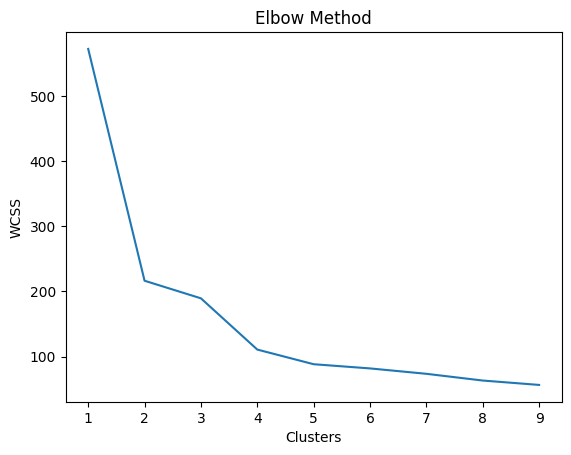

In [37]:
plt.plot(range(1,10), wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### 3. Final Model

In [39]:
kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_scaled)

data['Cluster'] = clusters

### 4. Visualization (2D)

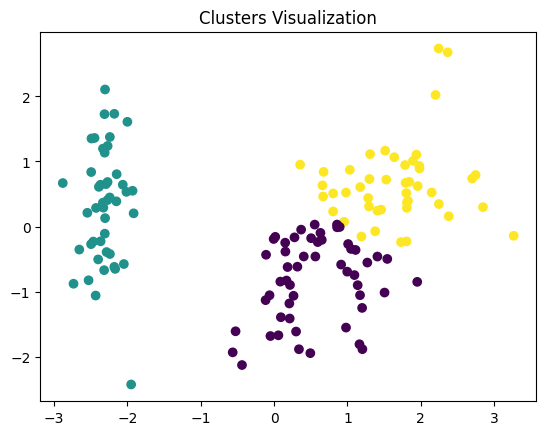

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Clusters Visualization")
plt.show()